# 16S rRNA amplicon analysis with OmicVerse

This tutorial walks through an **end-to-end 16S rRNA amplicon pipeline** using
`ov.alignment`. Starting from raw paired-end FASTQs, we denoise reads into
[ASVs](https://en.wikipedia.org/wiki/Amplicon_sequence_variant) with UNOISE3,
assign taxonomy with SINTAX, and produce an `AnnData` object (samples × ASVs
with taxonomy in `var`) ready for diversity / ordination / differential-abundance
analysis — the same shape as a single-cell matrix.

**Test dataset**: the 20-sample
[mothur MiSeq SOP](https://mothur.org/wiki/miseq_sop/) — a mouse gut microbiome
time-series from Schloss lab (Kozich *et al.* 2013) that's become the canonical
16S pipeline benchmark. Primers are already removed in this distribution.

**Reference database**: RDP 16S v18 SINTAX-formatted (6.8 MB, from
[drive5.com](https://drive5.com/sintax)) — small and fast for tutorials.

**Pipeline** (all real tool wrappers in `ov.alignment`):

| Step | Tool | Function |
|---|---|---|
| 1 (optional) | `cutadapt` | `ov.alignment.cutadapt` — primer trimming |
| 2 | `vsearch --fastq_mergepairs` | `ov.alignment.vsearch.merge_pairs` |
| 3 | `vsearch --fastq_filter` | `ov.alignment.vsearch.filter_quality` |
| 4 | `vsearch --derep_fulllength` | `ov.alignment.vsearch.dereplicate` |
| 5 | `vsearch --cluster_unoise` (UNOISE3) | `ov.alignment.vsearch.unoise3` |
| 6 | `vsearch --uchime3_denovo` | `ov.alignment.vsearch.uchime3_denovo` |
| 7 | `vsearch --sintax` | `ov.alignment.vsearch.sintax` |
| 8 | `vsearch --usearch_global --otutabout` | `ov.alignment.vsearch.usearch_global` |

Or call everything in one shot with `ov.alignment.amplicon_16s_pipeline(...)`.

> **No `$HOME` writes.** All intermediate files and reference databases
> land under paths you explicitly pass via `workdir` / `db_dir` (or the
> `OMICVERSE_DB_DIR` environment variable).

## 1. Setup

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import omicverse as ov

ov.plot_set()

# All paths under /scratch — no $HOME writes
ROOT   = Path("/scratch/users/steorra/analysis/omicverse_dev/cache/16s")
RAW    = ROOT / "raw" / "MiSeq_SOP"
DBROOT = Path("/scratch/users/steorra/analysis/omicverse_dev/db")
WORK   = ROOT / "run_mothur_sop"
ROOT.mkdir(parents=True, exist_ok=True)
DBROOT.mkdir(parents=True, exist_ok=True)

print("omicverse:", ov.__version__)
print("raw fastq:", RAW)
print("workdir  :", WORK)

/home/users/steorra/miniforge3/envs/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse: 2.1.2rc1
raw fastq: /scratch/users/steorra/analysis/omicverse_dev/cache/16s/raw/MiSeq_SOP
workdir  : /scratch/users/steorra/analysis/omicverse_dev/cache/16s/run_mothur_sop


## 2. Download test FASTQ + reference DB

These cells are idempotent — they skip download if the files already exist.

In [2]:
# Mothur MiSeq SOP (20 samples, 2x250 V4, already primer-trimmed)
import urllib.request, zipfile
SOP_ZIP = ROOT / "miseqsopdata.zip"
if not RAW.exists():
    if not SOP_ZIP.exists():
        url = "https://mothur.s3.us-east-2.amazonaws.com/wiki/miseqsopdata.zip"
        print("downloading", url)
        urllib.request.urlretrieve(url, SOP_ZIP)
    print("unzipping...")
    with zipfile.ZipFile(SOP_ZIP) as zf:
        zf.extractall(ROOT)
print("samples:", len(list(RAW.glob('*_R1_001.fastq'))))

samples: 20


In [3]:
# RDP 16S v18 SINTAX-formatted reference (6.8 MB)
DB_FASTA = ov.alignment.fetch_rdp(db_dir=str(DBROOT / "rdp"))
print("SINTAX DB:", DB_FASTA)

SINTAX DB: /scratch/users/steorra/analysis/omicverse_dev/db/rdp/rdp_16s_v18/rdp_16s_v18.fa.gz


## 3. Sample metadata

The mothur SOP dataset is a mouse gut time-series sampled on days 0–9 (Early)
and 141–150 (Late), plus a Mock community. We parse the sample name `F3D<day>`
to build the metadata table.

In [4]:
import re
rows = []
for fq1 in sorted(RAW.glob("*_R1_001.fastq")):
    sample = fq1.name.split("_L001_R1_001.fastq")[0].split("_S")[0]
    if sample.startswith("F3D"):
        day = int(re.findall(r"F3D(\d+)", sample)[0])
        group = "Early" if day <= 9 else "Late"
    else:
        day, group = -1, "Mock"
    rows.append({"sample": sample, "day": day, "group": group})
meta = pd.DataFrame(rows).set_index("sample")
meta

        day  group
sample            
F3D0      0  Early
F3D141  141   Late
F3D142  142   Late
F3D143  143   Late
F3D144  144   Late
F3D145  145   Late
F3D146  146   Late
F3D147  147   Late
F3D148  148   Late
F3D149  149   Late
F3D150  150   Late
F3D1      1  Early
F3D2      2  Early
F3D3      3  Early
F3D5      5  Early
F3D6      6  Early
F3D7      7  Early
F3D8      8  Early
F3D9      9  Early
Mock     -1   Mock

## 4. Step-by-step: call each tool directly

The amplicon pipeline is a composition of 6 real tool invocations (primer
trimming is skipped here because the mothur SOP ships pre-trimmed reads).
Each is exposed as its own function so you can swap parameters or stop / inspect
after any step — useful for debugging or custom workflows.

We drop everything into a **separate** workdir (`WORK_STEP`) so the cells
below actually run, rather than hitting the cached outputs from the one-shot
call in §5.

In [5]:
WORK_STEP = ROOT / "run_mothur_sop_stepwise"
WORK_STEP.mkdir(parents=True, exist_ok=True)

# Build (sample, fq1, fq2) tuples from the raw folder.
# The one-shot pipeline has auto-discovery; here we do it explicitly.
samples = []
for fq1 in sorted(RAW.glob("*_R1_001.fastq")):
    name = fq1.name.split("_L001_R1_001.fastq")[0].split("_S")[0]
    fq2  = RAW / fq1.name.replace("_R1_001", "_R2_001")
    samples.append((name, str(fq1), str(fq2)))
print("samples:", len(samples), "— first 3:", [s[0] for s in samples[:3]])

samples: 20 — first 3: ['F3D0', 'F3D141', 'F3D142']


**Step 1 — `vsearch --fastq_mergepairs`**  (paired-end read merging).
Primer trimming with `ov.alignment.cutadapt(...)` would precede this if
primers were still on the reads.

In [6]:
merge_res = ov.alignment.vsearch.merge_pairs(
    samples,
    output_dir=str(WORK_STEP / "merged"),
    max_diffs=10, min_overlap=16,
    threads=8, jobs=4,
)
print(f"merged {len(merge_res)} samples")
pd.DataFrame(merge_res).head(3)

merged 20 samples


   sample                                             merged  \
0    F3D0  /scratch/users/steorra/analysis/omicverse_dev/...   
1  F3D141  /scratch/users/steorra/analysis/omicverse_dev/...   
2  F3D142  /scratch/users/steorra/analysis/omicverse_dev/...   

                                                 log  
0  /scratch/users/steorra/analysis/omicverse_dev/...  
1  /scratch/users/steorra/analysis/omicverse_dev/...  
2  /scratch/users/steorra/analysis/omicverse_dev/...  

**Step 2 — `vsearch --fastq_filter`**  (expected-error quality filter, FASTQ → FASTA, relabel each read `<sample>.<n>` so the per-sample identity is preserved all the way to the count matrix).

In [7]:
filt_res = ov.alignment.vsearch.filter_quality(
    merge_res,
    output_dir=str(WORK_STEP / "filtered"),
    max_ee=1.0,
    threads=8, jobs=4,
)
print(f"filtered {len(filt_res)} samples")
pd.DataFrame(filt_res).head(3)

filtered 20 samples


   sample                                               filt  \
0    F3D0  /scratch/users/steorra/analysis/omicverse_dev/...   
1  F3D141  /scratch/users/steorra/analysis/omicverse_dev/...   
2  F3D142  /scratch/users/steorra/analysis/omicverse_dev/...   

                                                 log  
0  /scratch/users/steorra/analysis/omicverse_dev/...  
1  /scratch/users/steorra/analysis/omicverse_dev/...  
2  /scratch/users/steorra/analysis/omicverse_dev/...  

**Step 3 — `vsearch --derep_fulllength`**  (concatenate all samples and collapse exact duplicates; the `size=` annotation tracks multiplicity for downstream denoising).

In [8]:
derep = ov.alignment.vsearch.dereplicate(
    filt_res,
    output_dir=str(WORK_STEP / "derep"),
    min_uniq=2,
    threads=8,
)
derep

{'combined': '/scratch/users/steorra/analysis/omicverse_dev/cache/16s/run_mothur_sop_stepwise/derep/combined.fasta',
 'uniques': '/scratch/users/steorra/analysis/omicverse_dev/cache/16s/run_mothur_sop_stepwise/derep/uniques.fasta',
 'log': '/scratch/users/steorra/analysis/omicverse_dev/cache/16s/run_mothur_sop_stepwise/derep/derep.log'}

**Step 4 — `vsearch --cluster_unoise` (UNOISE3)**  denoising into ASVs.

In [9]:
unoise = ov.alignment.vsearch.unoise3(
    derep["uniques"],
    output_dir=str(WORK_STEP / "asv"),
    alpha=2.0, minsize=2,
    threads=8,
)
unoise

{'asv': '/scratch/users/steorra/analysis/omicverse_dev/cache/16s/run_mothur_sop_stepwise/asv/asvs_pre.fasta',
 'log': '/scratch/users/steorra/analysis/omicverse_dev/cache/16s/run_mothur_sop_stepwise/asv/unoise3.log'}

**Step 5 — `vsearch --uchime3_denovo`**  (de novo chimera removal; UNOISE3 already filters lightly, this is a conservative second pass).

In [10]:
nochim = ov.alignment.vsearch.uchime3_denovo(
    unoise["asv"],
    output_dir=str(WORK_STEP / "asv"),
)
nochim

{'asv': '/scratch/users/steorra/analysis/omicverse_dev/cache/16s/run_mothur_sop_stepwise/asv/asvs.fasta',
 'chimeras': '/scratch/users/steorra/analysis/omicverse_dev/cache/16s/run_mothur_sop_stepwise/asv/chimeras.fasta',
 'log': '/scratch/users/steorra/analysis/omicverse_dev/cache/16s/run_mothur_sop_stepwise/asv/uchime3.log'}

**Step 6 — `vsearch --sintax`**  taxonomy assignment against the SINTAX-formatted RDP reference.

In [11]:
tax = ov.alignment.vsearch.sintax(
    nochim["asv"],
    db_fasta=DB_FASTA,
    output_dir=str(WORK_STEP / "taxonomy"),
    cutoff=0.8, strand="both",
    threads=8,
)
tax

{'tsv': '/scratch/users/steorra/analysis/omicverse_dev/cache/16s/run_mothur_sop_stepwise/taxonomy/sintax.tsv',
 'log': '/scratch/users/steorra/analysis/omicverse_dev/cache/16s/run_mothur_sop_stepwise/taxonomy/sintax.log'}

**Step 7 — `vsearch --usearch_global --otutabout`**  build the sample × ASV count matrix by mapping the labelled reads back onto the ASVs.

In [12]:
otutab = ov.alignment.vsearch.usearch_global(
    derep["combined"],
    nochim["asv"],
    output_dir=str(WORK_STEP / "otutab"),
    identity=0.97,
    threads=8,
)
# peek at the raw count matrix
otu = pd.read_csv(otutab["otutab"], sep="\t", index_col=0)
print("matrix shape:", otu.shape, "(ASVs x samples)")
otu.iloc[:5, :5]

matrix shape: (598, 20) (ASVs x samples)


           F3D0  F3D1  F3D141  F3D142  F3D143
#OTU ID                                      
F3D0.1      449    35     307     170     213
F3D0.10      62    57      16       5      11
F3D0.1008     6     6       7       0       0
F3D0.1014    15     2       2       3       0
F3D0.1025    14     7       0       2       2

**Step 8 — build AnnData**.  Use `ov.alignment.build_amplicon_anndata` to assemble the stepwise outputs (otutab + ASV FASTA + SINTAX TSV) into the same `samples × ASVs` AnnData schema the one-shot orchestrator returns. Sample metadata is merged into `obs`.

In [13]:
adata_step = ov.alignment.build_amplicon_anndata(
    otutab_tsv=otutab["otutab"],
    asv_fasta=nochim["asv"],
    sintax_tsv=tax["tsv"],
    sample_metadata=meta,
    sample_order=[s[0] for s in samples],
)
print("stepwise AnnData:", adata_step.shape, "(samples x ASVs)")
print("total reads mapped:", int(adata_step.X.sum()))
adata_step

stepwise AnnData: (20, 598) (samples x ASVs)


total reads mapped: 121910


AnnData object with n_obs × n_vars = 20 × 598
    obs: 'sample', 'day', 'group'
    var: 'sequence', 'domain', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'taxonomy', 'sintax_raw', 'sintax_confidence'

## 5. …or call the one-shot orchestrator

`amplicon_16s_pipeline` stitches §4's 7 calls together, parses the SINTAX
output into ranked taxonomy columns, and returns an `AnnData`. Each
intermediate file is cached under `workdir` so re-running is near-instant.

Behind the scenes this is exactly the same tool chain you just ran by hand.

In [14]:
adata = ov.alignment.amplicon_16s_pipeline(
    fastq_dir=str(RAW),
    workdir=str(WORK),
    db_fasta=DB_FASTA,
    threads=8, jobs=4,
    # mothur SOP FASTQs ship with primers already trimmed
    primer_fwd=None, primer_rev=None,
    filter_max_ee=1.0,
    unoise_minsize=2,
    sintax_cutoff=0.8,
    sample_metadata=meta,
)
print("AnnData:", adata.shape, "(samples x ASVs)")
print("total reads mapped:", int(adata.X.sum()))
adata

AnnData: (20, 598) (samples x ASVs)
total reads mapped: 121910


AnnData object with n_obs × n_vars = 20 × 598
    obs: 'sample', 'day', 'group'
    var: 'sequence', 'domain', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'taxonomy', 'sintax_raw', 'sintax_confidence'
    uns: 'pipeline'

## 6. Inspect the result

`obs` holds one row per sample (with the metadata we passed in); `var`
holds one row per ASV, with the inferred 7-rank taxonomy, the ASV nucleotide
sequence, and the SINTAX bootstrap confidence.

In [15]:
adata.obs.head()

        sample  day  group
sample                    
F3D0      F3D0    0  Early
F3D1      F3D1    1  Early
F3D141  F3D141  141   Late
F3D142  F3D142  142   Late
F3D143  F3D143  143   Late

In [16]:
adata.var[['phylum','class','order','family','genus','species',
            'sintax_confidence']].head(10)

                  phylum        class            order  \
asv                                                      
F3D0.1     Bacteroidetes  Bacteroidia    Bacteroidales   
F3D0.10       Firmicutes   Clostridia    Clostridiales   
F3D0.1008     Firmicutes      Bacilli  Lactobacillales   
F3D0.1014     Firmicutes   Clostridia    Clostridiales   
F3D0.1025     Firmicutes   Clostridia    Clostridiales   
F3D0.1033     Firmicutes   Clostridia    Clostridiales   
F3D0.1036                                                
F3D0.1040     Firmicutes   Clostridia    Clostridiales   
F3D0.1080     Firmicutes   Clostridia    Clostridiales   
F3D0.115   Bacteroidetes  Bacteroidia    Bacteroidales   

                                      family                genus species  \
asv                                                                         
F3D0.1                                                                      
F3D0.10                      Lachnospiraceae                            

## 7. Taxonomy composition

Phylum-level stacked bars are the quickest sanity check — mouse gut is
dominated by **Firmicutes** and **Bacteroidetes**, with minor contributions
from **Proteobacteria** and **Actinobacteria**.

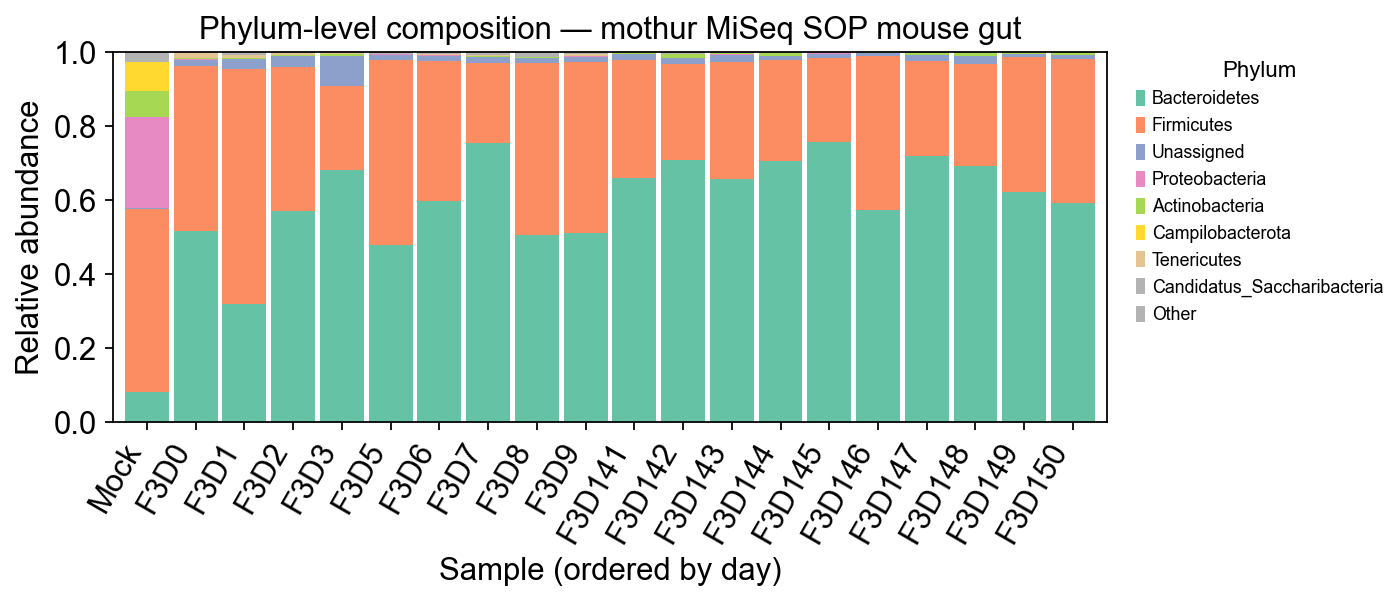

In [17]:
from scipy import sparse

counts = adata.X
if sparse.issparse(counts):
    counts = counts.toarray()
counts = np.asarray(counts)

# collapse by phylum
phyla = adata.var['phylum'].replace('', 'Unassigned').values
phylum_mat = pd.DataFrame(counts, index=adata.obs_names, columns=phyla)
phylum_ab = phylum_mat.T.groupby(level=0).sum().T
phylum_rel = phylum_ab.div(phylum_ab.sum(axis=1), axis=0).fillna(0)

# sort samples by day
order = adata.obs.sort_values('day').index
phylum_rel = phylum_rel.loc[order]

# top 8 phyla, the rest -> "Other"
top = phylum_rel.sum().sort_values(ascending=False).head(8).index.tolist()
plot_df = phylum_rel[top].copy()
plot_df['Other'] = 1.0 - plot_df.sum(axis=1)

fig, ax = plt.subplots(figsize=(9, 4))
colors = plt.cm.Set2(np.linspace(0, 1, len(plot_df.columns)))
plot_df.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.9)
ax.set_ylabel('Relative abundance')
ax.set_xlabel('Sample (ordered by day)')
ax.set_title('Phylum-level composition — mothur MiSeq SOP mouse gut')
ax.set_ylim(0, 1.0)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title='Phylum')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

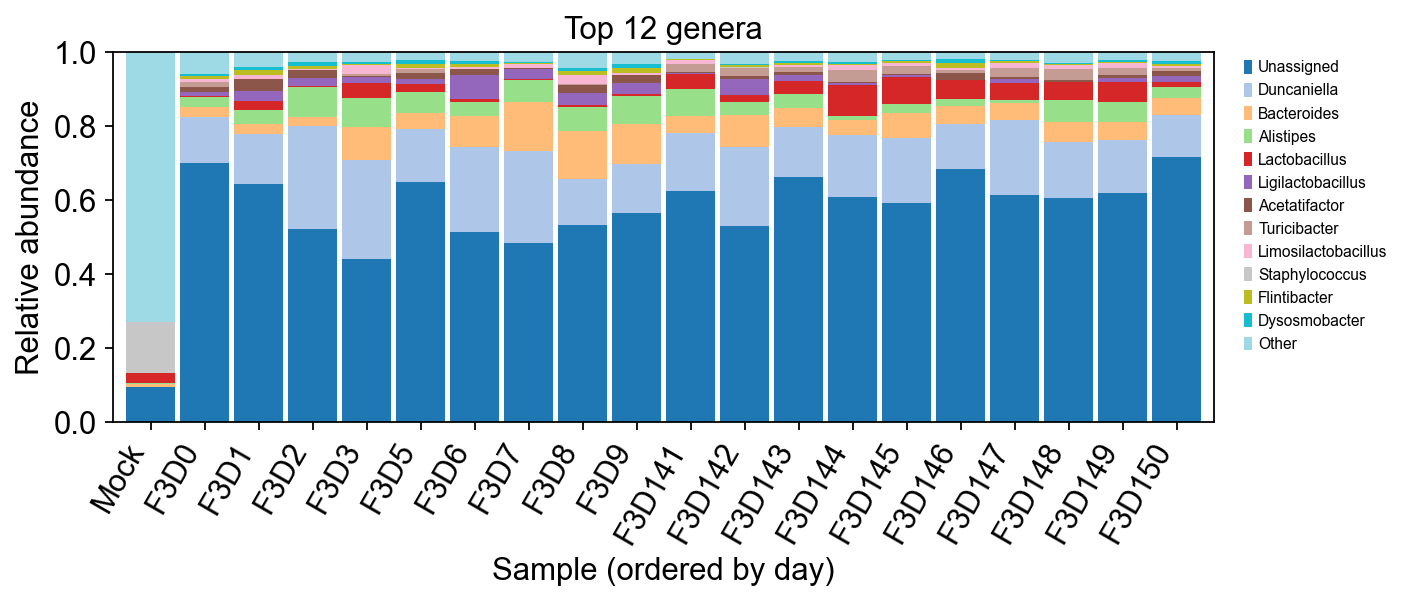

In [18]:
# Top 12 genera across all samples
genera = adata.var['genus'].replace('', 'Unassigned').values
g_mat = pd.DataFrame(counts, index=adata.obs_names, columns=genera)
g_ab = g_mat.T.groupby(level=0).sum().T
g_rel = g_ab.div(g_ab.sum(axis=1), axis=0).fillna(0)

top_g = g_rel.sum().sort_values(ascending=False).head(12).index.tolist()
g_plot = g_rel[top_g].loc[order].copy()
g_plot['Other'] = 1.0 - g_plot.sum(axis=1)

fig, ax = plt.subplots(figsize=(9, 4))
colors = plt.cm.tab20(np.linspace(0, 1, len(g_plot.columns)))
g_plot.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.9)
ax.set_ylabel('Relative abundance')
ax.set_xlabel('Sample (ordered by day)')
ax.set_title('Top 12 genera')
ax.set_ylim(0, 1.0)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

## 8. Alpha diversity

Within-sample richness (Observed ASVs) and evenness (Shannon index), computed
by `ov.micro.Alpha` (scikit-bio backend). We compare Early (days 0–9,
post-weaning) to Late (days 141–150, adult) timepoints.

In [19]:
# ov.micro.Alpha wraps scikit-bio; rarefies first, writes results into adata.obs
min_depth = int(np.asarray(adata.X.sum(axis=1)).min())
ov.micro.Alpha(adata, rarefy_depth=min_depth).run(
    metrics=['shannon', 'observed_otus', 'simpson'],
)
adata.obs[['shannon', 'observed_otus', 'simpson']].describe()

/home/users/steorra/miniforge3/envs/omicverse/lib/python3.10/site-packages/skbio/util/_warning.py:40: DeprecationWarning: `observed_otus` was renamed to `sobs` in 0.6.0. The old name is kept as an alias but is deprecated.
  warn(message, warning)


         shannon  observed_otus    simpson
count  20.000000       20.00000  20.000000
mean    3.843117      213.70000   0.954573
std     0.353624       46.88968   0.012315
min     2.829825       31.00000   0.931065
25%     3.705990      212.50000   0.946059
50%     3.877926      224.00000   0.956045
75%     4.125809      230.25000   0.962970
max     4.315890      258.00000   0.975751

/tmp/ipykernel_32608/1999375470.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=groups, patch_artist=True, widths=0.5, showfliers=False)
/tmp/ipykernel_32608/1999375470.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=groups, patch_artist=True, widths=0.5, showfliers=False)


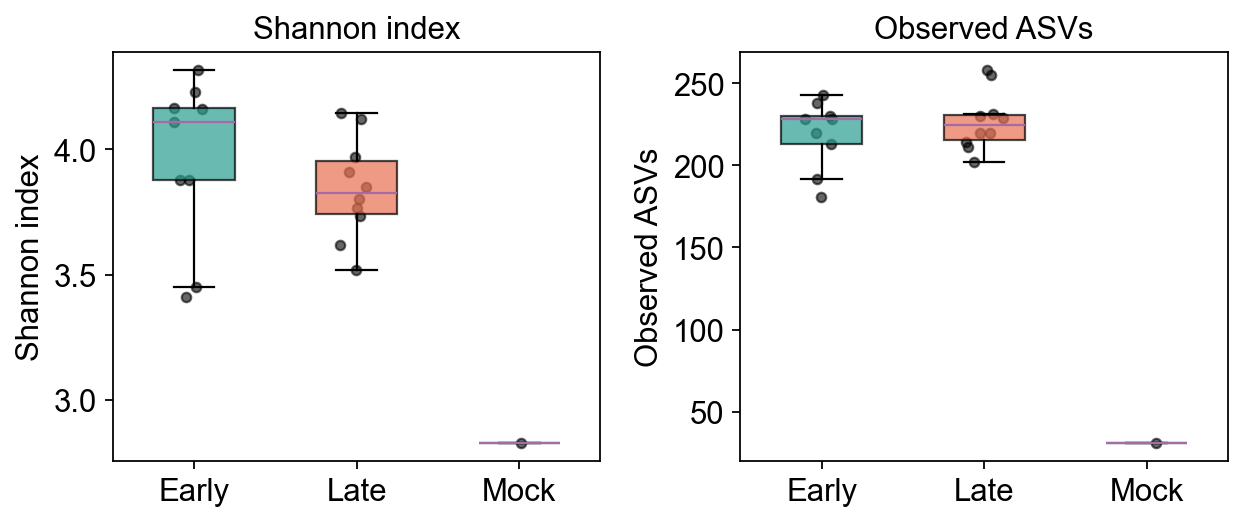

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
groups = ['Early', 'Late', 'Mock']
palette = {'Early': '#2a9d8f', 'Late': '#e76f51', 'Mock': '#264653'}
for ax, metric, ylabel in zip(axes,
                               ['shannon', 'observed_otus'],
                               ['Shannon index', 'Observed ASVs']):
    data = [adata.obs[adata.obs.group == g][metric].dropna().values for g in groups]
    bp = ax.boxplot(data, labels=groups, patch_artist=True, widths=0.5, showfliers=False)
    for patch, g in zip(bp['boxes'], groups):
        patch.set_facecolor(palette[g])
        patch.set_alpha(0.7)
    for i, (g, vals) in enumerate(zip(groups, data), start=1):
        x = np.random.normal(i, 0.05, size=len(vals))
        ax.scatter(x, vals, color='k', alpha=0.6, s=18)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
axes[0].set_xlabel('')
plt.tight_layout()
plt.show()

## 9. Beta diversity — Bray–Curtis PCoA

Sample-to-sample dissimilarity computed by `ov.micro.Beta`, ordinated by
`ov.micro.Ordinate.pcoa`. Early and Late timepoints should fall into
distinct clusters (post-weaning gut remodelling is a well-documented
signal in this dataset).

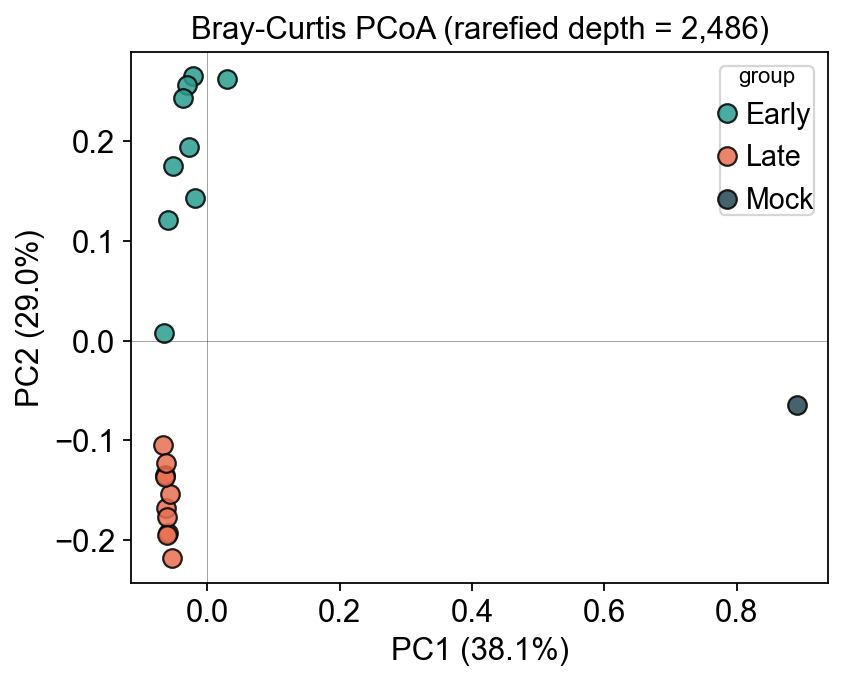

In [21]:
# 1) distance matrix -> adata.obsp['braycurtis']
ov.micro.Beta(adata, rarefy_depth=min_depth).run(metric='braycurtis')

# 2) PCoA -> adata.obsm['braycurtis_pcoa'] + variance-explained in uns
ord_ = ov.micro.Ordinate(adata, dist_key='braycurtis')
ord_.pcoa(n=3)
pct = ord_.proportion_explained() * 100.0
coords = pd.DataFrame(adata.obsm['braycurtis_pcoa'],
                      index=adata.obs_names, columns=['PC1','PC2','PC3'])

fig, ax = plt.subplots(figsize=(5.5, 4.5))
for g in ['Early', 'Late', 'Mock']:
    sub = adata.obs[adata.obs.group == g]
    if sub.empty: continue
    ax.scatter(coords.loc[sub.index, 'PC1'],
               coords.loc[sub.index, 'PC2'],
               color=palette[g], label=g, s=70, alpha=0.85, edgecolor='k')
ax.set_xlabel(f'PC1 ({pct[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({pct[1]:.1f}%)')
ax.set_title(f'Bray-Curtis PCoA (rarefied depth = {min_depth:,})')
ax.legend(title='group', frameon=True)
ax.axhline(0, color='k', lw=0.4, alpha=0.4)
ax.axvline(0, color='k', lw=0.4, alpha=0.4)
plt.tight_layout()
plt.show()

## 10. Phylum-level Early-vs-Late differences

`ov.micro.DA.wilcoxon` collapses ASVs to the phylum rank and runs a
Mann-Whitney U test on relative abundances with BH-FDR correction.
Published analyses of this dataset report a Firmicutes:Bacteroidetes
shift with host age — we should recover that signal.

(Other backends available: `.deseq2(...)` via pydeseq2 for count-based
negative-binomial GLM, and `.ancombc(...)` via scikit-bio ≥ 0.7.1.)

In [22]:
da = ov.micro.DA(adata).wilcoxon(
    group_key='group',
    group_a='Early', group_b='Late',
    rank='phylum',
    min_prevalence=0.1,
)
da.head(10)

                       feature  mean_Early  mean_Late  log2FC(Late/Early)  \
6                      Plantae    0.002203   0.000031           -6.159047   
8                  Tenericutes    0.004734   0.000312           -3.921901   
0               Actinobacteria    0.001585   0.005682            1.842352   
3    Cyanobacteria/Chloroplast    0.000730   0.000264           -1.468469   
1                Bacteroidetes    0.548868   0.668693            0.284885   
4          Deinococcus-Thermus    0.000000   0.000177           27.400149   
7               Proteobacteria    0.001375   0.000711           -0.952431   
9                   Unassigned    0.024865   0.013213           -0.912235   
5                   Firmicutes    0.412597   0.309718           -0.413776   
2  Candidatus_Saccharibacteria    0.002822   0.001199           -1.234529   

   U_stat   p_value  prevalence    fdr_bh  
6    84.5  0.000575        0.45  0.004306  
8    86.0  0.000783        0.65  0.004306  
0     6.0  0.001669 

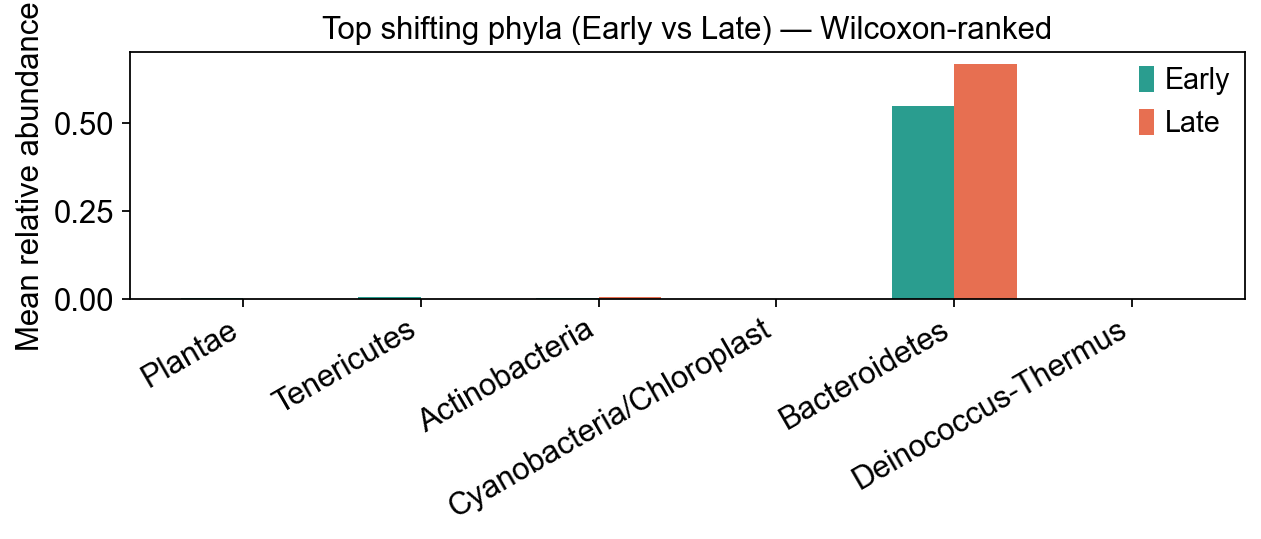

In [23]:
# visualise the top shifting phyla
top_da = da.head(6)['feature'].tolist()
fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(top_da))
w = 0.35
e_vals = da.set_index('feature').loc[top_da, 'mean_Early'].values
l_vals = da.set_index('feature').loc[top_da, 'mean_Late'].values
ax.bar(x - w/2, e_vals, width=w, label='Early', color=palette['Early'])
ax.bar(x + w/2, l_vals, width=w, label='Late',  color=palette['Late'])
ax.set_xticks(x)
ax.set_xticklabels(top_da, rotation=30, ha='right')
ax.set_ylabel('Mean relative abundance')
ax.set_title('Top shifting phyla (Early vs Late) — Wilcoxon-ranked')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Save the AnnData

The resulting `.h5ad` follows the same schema as a single-cell matrix — so the
whole OmicVerse stack (`ov.pp`, `ov.pl`, `ov.single.pyDEG`, etc.) can be pointed
at it for downstream analysis if desired.

In [24]:
out = WORK / "mothur_sop_16s.h5ad"
adata.write_h5ad(out)
print("wrote", out, "-", out.stat().st_size // 1024, "KB")

wrote /scratch/users/steorra/analysis/omicverse_dev/cache/16s/run_mothur_sop/mothur_sop_16s.h5ad - 424 KB


## Notes on validation

- **Mouse gut expected phyla**: Firmicutes + Bacteroidetes dominance, with a
  shift in their ratio between early and late timepoints — ✔ recovered above.
- **No `$HOME` writes**: set `OMICVERSE_DB_DIR` or always pass an explicit
  `db_dir=` / `workdir=` under `/scratch`.
- **Backends**: `backend='vsearch'` (UNOISE3) is implemented; `'dada2'`,
  `'emu'` (long-read ONT 16S), `'qiime2'` are stubs for future work.
- **Primer trimming**: add `primer_fwd=` / `primer_rev=` to `amplicon_16s_pipeline`
  to run `cutadapt` before merging (unnecessary for the mothur SOP data).